Modèle prédictif de la sensibilité aux allergies, basé sur un Random Forest Classifier, utilisant les colonnes des résultats de biologie, sans les regrouper.

In [32]:
import pandas as pd
import sqlite3

# Dans le fichier BRUT, il y a 4,271 lignes. On a nettoyé ce fichier.
# Dans le fichier CLEAN, il y a 4,145 lignes.
db_path = "../data/allergen_chip_challenge.db"

# On va lire les données allergies directement depuis la table dans la base de données :
conn = sqlite3.connect(db_path)

df = pd.read_sql("Select * From allergies", conn)
conn.close()

df.shape

(4145, 255)

In [33]:
df.iloc[:, 0:10].head()

,Patient_ID,Chip_Type,Age,Gender,Blood_Month_sample,Region,Rural_area,Sensitization,Treatment_of_rhinitis,Treatment_of_asthma
0,FHB0001,ISAC_V1,20 à 40,1,11.0,regionB,0,1,Non renseigné,0
1,FHB0002,ISAC_V1,40 à 60,0,12.0,regionB,0,1,Non renseigné,0
2,FHB0003,ISAC_V1,10 à 20,1,1.0,regionB,0,0,Anti-H1 voie générale,0
3,FHB0004,ISAC_V1,10 à 20,0,1.0,regionB,0,1,Non renseigné,0
4,FHB0005,ISAC_V1,20 à 40,0,1.0,regionB,0,1,Non renseigné,0


In [34]:
df["Rural_area"].value_counts()

Rural_area
0    3179
1     966
Name: count, dtype: int64

In [35]:
df["Treatment_of_rhinitis"].value_counts()

Treatment_of_rhinitis
Non renseigné            2832
Aucun                     883
Anti-H1 voie générale     223
Anti-H1 + CS              115
Anti-H1, voie locale       92
Name: count, dtype: int64

In [36]:
df.iloc[:, 10:20].head()

,Age_of_onsets,Skin_Symptoms,General_cofactors,Treatment_of_atopic_dematitis,Act_d_1,Act_d_2,Act_d_5,Act_d_8,Aln_g_1,Alt_a_1
0,Non renseigné,0,Aucun,Non renseigné,0.0,0.0,0.0,0.0,0.00,0.0
1,Non renseigné,0,Aucun,Non renseigné,0.0,0.0,0.0,6.0,19.32,0.0
2,Aucun,0,Acariens,Non renseigné,0.0,0.0,0.0,0.0,0.00,0.0
3,Non renseigné,0,Aucun,Non renseigné,0.0,0.0,0.0,0.0,13.42,0.0
4,Non renseigné,0,Aucun,Non renseigné,0.0,0.0,0.0,0.0,0.00,0.0


In [37]:
df["Treatment_of_asthma"].value_counts()

Treatment_of_asthma
0    3542
1     603
Name: count, dtype: int64

In [38]:
df["Age_of_onsets"].value_counts()

Age_of_onsets
Non renseigné     2446
Aucun              622
0 - 2 ans          350
3 - 10 ans         296
20 ans et plus     150
10 - 20 ans        147
2 - 3 ans          134
Name: count, dtype: int64

In [39]:
df["Skin_Symptoms"].value_counts()

Skin_Symptoms
0    3005
1    1140
Name: count, dtype: int64

In [40]:
df["General_cofactors"].value_counts()

General_cofactors
Aucun                       3009
Animaux : cheval/rongeur     794
Effort/Activité sportive     141
Animaux : chat/chien          87
Acariens                      57
Moisissures                   36
Autres                        21
Name: count, dtype: int64

In [41]:
df["Treatment_of_atopic_dematitis"].value_counts()

Treatment_of_atopic_dematitis
Non renseigné        2563
Pas de traitement    1294
Dermocorticoïdes      122
Dupilumab              84
Autres                 82
Name: count, dtype: int64

In [42]:
df["Age"].value_counts()

Age
10 à 20      1236
0 à 10       1136
20 à 40       922
40 à 60       616
60 à Plus     235
Name: count, dtype: int64

In [43]:
df.shape

(4145, 255)

In [44]:
df2 = df.drop_duplicates()

df2.shape

(4145, 255)

In [45]:
# Choix parmi 241 colonnes de réactifs d'allergènes. Les corrélations avec la colonne globale de sensibilité permet d'isoler les meilleurs indicateurs.

corr_sensitization = []
best_corr_sensitization = []
best_columns = []
all_cols = df2.columns

for i in range(14, len(all_cols)):
    col = all_cols[i]
    c = df2[["Sensitization", col]].corr()
    value = float(c.iloc[0, 1])
    cval = value, col
    corr_sensitization.append(cval)

corr_sensitization.sort(reverse=True)
# Les 25 meilleures corrélations avec la variable cible :
best_corr_sensitization = corr_sensitization[:25]
best_columns = [z[1] for z in best_corr_sensitization]

best_corr_sensitization

[(0.1914861355745523, 'Phl_p_1'),
 (0.18799315902329816, 'Der_f_2'),
 (0.18312291400122632, 'Der_p_2'),
 (0.1653213192995305, 'Der_p_1'),
 (0.16110494552900706, 'Der_f_1'),
 (0.16083187764822515, 'Fel_d_1'),
 (0.15923882605423964, 'Bet_v_1'),
 (0.14179536095803771, 'Cup_a_1'),
 (0.13186766960397997, 'Ole_e_1'),
 (0.1317138782166565, 'Cyn_d_1'),
 (0.12598058665016984, 'Phl_p_5'),
 (0.12413674923742744, 'Phl_p_2'),
 (0.12157587284363593, 'Cor_a_1.0401'),
 (0.11653748812479325, 'Mal_d_1'),
 (0.11469993316951071, 'Cry_j_1'),
 (0.11302393123885372, 'Alt_a_1'),
 (0.10770987507880439, 'Phl_p_4'),
 (0.10761203641969452, 'Aln_g_1'),
 (0.10328696311313916, 'Phl_p_6'),
 (0.10245906877426018, 'Ara_h_6'),
 (0.09980231108965638, 'Ara_h_2'),
 (0.09928997800894515, 'Lol_p_1'),
 (0.094581717798989, 'Can_f_1'),
 (0.09083756337466939, 'Cor_a_1.0101'),
 (0.08992696637549344, 'Cor_a_1.0103')]

In [46]:
# On force l'ajout du lait de vache, et du chien parmi les colonnes explicatives :
best_columns.append("Bos_d_8")
best_columns.append("Can_f_1")

# On enlève Der_p_1, Der_p_2 (car il est très similaire aux autres colonnes des acariens, Der_f_1, Der_f_2 est le gène majeur) :
if "Der_p_1" in best_columns:
    best_columns.remove("Der_p_1")
if "Der_p_2" in best_columns:
    best_columns.remove("Der_p_2")
# On enlève aussi Cor_a_1.0401 (la colonne entraîne de la colinéarité avec plusieurs colonnes)
if "Cor_a_1.0401" in best_columns:
    best_columns.remove("Cor_a_1.0401")

# On veut être sûr qu'il n'y a pas de doublons :
best_columns = list(set(best_columns))

len(best_columns)

23

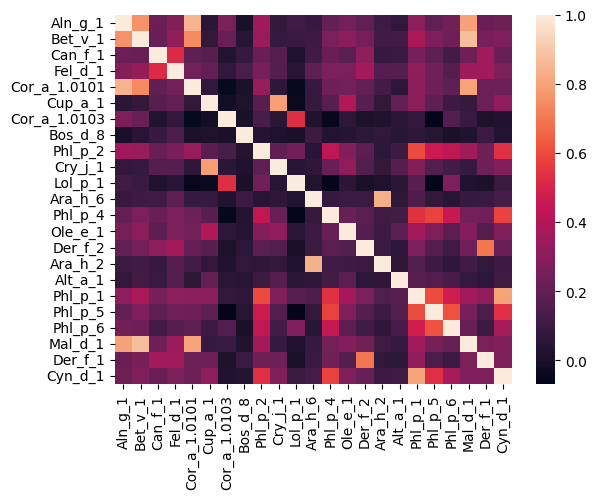

In [47]:
import seaborn as sns
from matplotlib import pyplot as plt

corr_df = df2[best_columns].corr()


# On peut (en forçant) ajouter des colonnes intéressantes (lait de vache, chien) relatives aux allergènes très courants.
# Lait de vache ==> Bos_d_8
# Chien         ==> Can_f_1

# Attention, il subsiste quelques colonnes qui sont corrélées entre elles, cela risque d'altérer le modèle prédictif.

sns.heatmap(corr_df)
plt.show()

In [48]:
left_columns = []

# Taking columns from the left hand, but not the row-id neither the Patient_ID:
for i in range(1, 14):
    left_columns.append(all_cols[i])

left_columns

['Chip_Type',
 'Age',
 'Gender',
 'Blood_Month_sample',
 'Region',
 'Rural_area',
 'Sensitization',
 'Treatment_of_rhinitis',
 'Treatment_of_asthma',
 'Age_of_onsets',
 'Skin_Symptoms',
 'General_cofactors',
 'Treatment_of_atopic_dematitis']

In [49]:
columns_to_keep = left_columns + best_columns

print(f"We will keep {len(columns_to_keep)} columns, as they seem interesting")

We will keep 36 columns, as they seem interesting


In [50]:
col_that_need_dummies = ['Chip_Type', 'Age', 'Blood_Month_sample', 'Region', 'Treatment_of_rhinitis', 'Age_of_onsets', 'General_cofactors', 'Treatment_of_atopic_dematitis']

# We keep only the columns to keep, and (for the pure categorical columns) we make some dummies.
df2 = df2[columns_to_keep]
df3 = pd.get_dummies(data=df2, columns=col_that_need_dummies, drop_first=True)

df3.shape


(4145, 75)

In [51]:
df3.head()

,Gender,Rural_area,Sensitization,Treatment_of_asthma,Skin_Symptoms,Aln_g_1,Bet_v_1,Can_f_1,Fel_d_1,Cor_a_1.0101,...,General_cofactors_Animaux : chat/chien,General_cofactors_Animaux : cheval/rongeur,General_cofactors_Aucun,General_cofactors_Autres,General_cofactors_Effort/Activité sportive,General_cofactors_Moisissures,Treatment_of_atopic_dematitis_Dermocorticoïdes,Treatment_of_atopic_dematitis_Dupilumab,Treatment_of_atopic_dematitis_Non renseigné,Treatment_of_atopic_dematitis_Pas de traitement
0,1,0,1,0,0,0.00,0.00,0.0,0.00,0.00,...,False,False,True,False,False,False,False,False,True,False
1,0,0,1,0,0,19.32,85.74,0.0,0.00,23.42,...,False,False,True,False,False,False,False,False,True,False
2,1,0,0,0,0,0.00,0.00,0.0,0.00,0.00,...,False,False,False,False,False,False,False,False,True,False
3,0,0,1,0,0,13.42,41.95,0.0,0.72,8.32,...,False,False,True,False,False,False,False,False,True,False
4,0,0,1,0,0,0.00,0.00,0.0,0.00,0.00,...,False,False,True,False,False,False,False,False,True,False


In [52]:
# Nous ne devrions jamais avoir de valeurs négatives dans le "min" de nos variables :

df3.iloc[:, 5:15].describe()

,Aln_g_1,Bet_v_1,Can_f_1,Fel_d_1,Cor_a_1.0101,Cup_a_1,Cor_a_1.0103,Bos_d_8,Phl_p_2,Cry_j_1
count,4145.000000,4145.000000,4145.000000,4145.000000,4145.000000,4145.000000,4145.000000,4145.000000,4145.000000,4145.000000
mean,2.170294,8.508994,2.808799,6.663407,1.743795,6.043397,1.226417,0.525597,3.260922,1.533276
std,8.584514,22.767439,12.655987,17.656858,8.180710,18.146067,5.809374,4.069923,11.194619,5.679253
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.100000,2.110000,0.000000,4.090000,0.000000,0.910000,0.000000,0.000000,0.000000,0.230000
max,170.750000,221.560000,185.180000,222.610000,184.380000,222.720000,55.850000,118.660000,159.800000,126.510000


In [53]:
from sklearn.model_selection import train_test_split

# Définition des colonnes qui sont dans X, et de la colonne qui est dans y :
X = df3.drop(columns=["Sensitization"])
y = df3["Sensitization"]


X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# On peut centrer/réduire les données avec un SCALER (de type Standard {basé sur la moyenne} ou Robust {basé sur la médiane}) :

from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
scaler.set_output(transform="pandas")

# Transformation autant pour X_train que pour X_test :
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)



In [54]:
X_train.head()

,Gender,Rural_area,Treatment_of_asthma,Skin_Symptoms,Aln_g_1,Bet_v_1,Can_f_1,Fel_d_1,Cor_a_1.0101,Cup_a_1,...,General_cofactors_Animaux : chat/chien,General_cofactors_Animaux : cheval/rongeur,General_cofactors_Aucun,General_cofactors_Autres,General_cofactors_Effort/Activité sportive,General_cofactors_Moisissures,Treatment_of_atopic_dematitis_Dermocorticoïdes,Treatment_of_atopic_dematitis_Dupilumab,Treatment_of_atopic_dematitis_Non renseigné,Treatment_of_atopic_dematitis_Pas de traitement
725,-1.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.004670,0.0,0.191919,...,0.0,1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1065,-1.0,1.0,0.0,1.0,0.000000,0.000000,0.0,0.000000,0.0,0.070707,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,1.0
1267,0.0,0.0,0.0,0.0,198.896552,20.591515,0.0,0.424985,0.0,0.050505,...,0.0,1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1282,-1.0,1.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,0.0,1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2337,-1.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [55]:
# Lorsque les données à analyser sont "scalées" avec un Robust Scaler, et qu'on choisit un Random Forest Classifier, le score
# du modèle peut atteindre 0.92

from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier()

rfc.fit(X=X_train, y=y_train)

score = rfc.score(X=X_test, y=y_test)

# Bon score : plus de 0.92
print("Score du modèle Random Forest Classifier")
print(score)

Score du modèle Random Forest Classifier
0.9199614271938283


In [56]:
my_cols = X_train.columns
should_remove = []

for my_col in my_cols:
    lbl = f"Without {my_col}"
    X_train_z = X_train.drop(columns=my_col)
    X_test_z = X_test.drop(columns=my_col)
    rfc_z = RandomForestClassifier()
    rfc_z.fit(X=X_train_z, y=y_train)
    score_z = rfc_z.score(X=X_test_z, y=y_test)
    if score_z > (score + 0.01):
        should_remove.append([score_z, lbl])

should_remove.sort(reverse=True)

print(f"Current score = {score}")
should_remove


Current score = 0.9199614271938283


[]

In [57]:
nb_pathologiques = y_test.sum()
y_est = rfc.predict(X_test)
nb_pathologiques_pred = y_est.sum()

total_obs = len(y_test)

true_positive = (y_est==1) & (y_test==1)
nb_true_positive = true_positive.sum()

print(f"nb_pathologiques={nb_pathologiques}, nb_pathologiques_pred={nb_pathologiques_pred}, total_obs={total_obs}")

# Précision : ensemble des vrais positifs / ensemble des prédictions positives
PRECISION = nb_true_positive / nb_pathologiques_pred
naive_precision = nb_pathologiques / len(y_test)
print(f"PRECISION = {PRECISION}, NAIVE-PRECISION (baseline) = {naive_precision}")

# Recall : ensemble des vrais positifs / ensemble des positifs réels
RECALL = nb_true_positive / nb_pathologiques
print(f"RECALL = {RECALL}")

F1_Score = 2 * (PRECISION*RECALL) / (PRECISION+RECALL)
print(f"F1_Score = {F1_Score}")

nb_pathologiques=856, nb_pathologiques_pred=847, total_obs=1037
PRECISION = 0.9563164108618654, NAIVE-PRECISION (baseline) = 0.8254580520732884
RECALL = 0.9462616822429907
F1_Score = 0.9512624779800353


In [58]:
print(f"Rows in y_est = {len(y_est)}, Mean of sensitization estimated = {y_est.mean()}")

Rows in y_est = 1037, Mean of sensitization estimated = 0.8167791706846673


In [59]:
allergens_df = pd.read_csv("../data/allergens.csv")

allergens_df.head()

,allergen,name,molecular_mass,route
0,Aca f 1,Ole e 1-like protein,17 kDa,Airway
1,Aca f 2,Profilin,14.3 kDa,Airway
2,Aca s 13,Cytosolic fatty acid-binding protein,15 kDa,Airway
3,Aca s 2,NPC2 family; MD-2-related lipid recognition (M...,14 kDa,Airway
4,Act c 10,Non-specific lipid transfer protein type 1 (ns...,10 kDa,Food


In [60]:
dico = {}
for i in range(len(allergens_df)):
    dico[allergens_df.iloc[i, 0].strip()] = f"{allergens_df.iloc[i, 1]} / {allergens_df.iloc[i, 3]}"

len(allergens_df)

1155

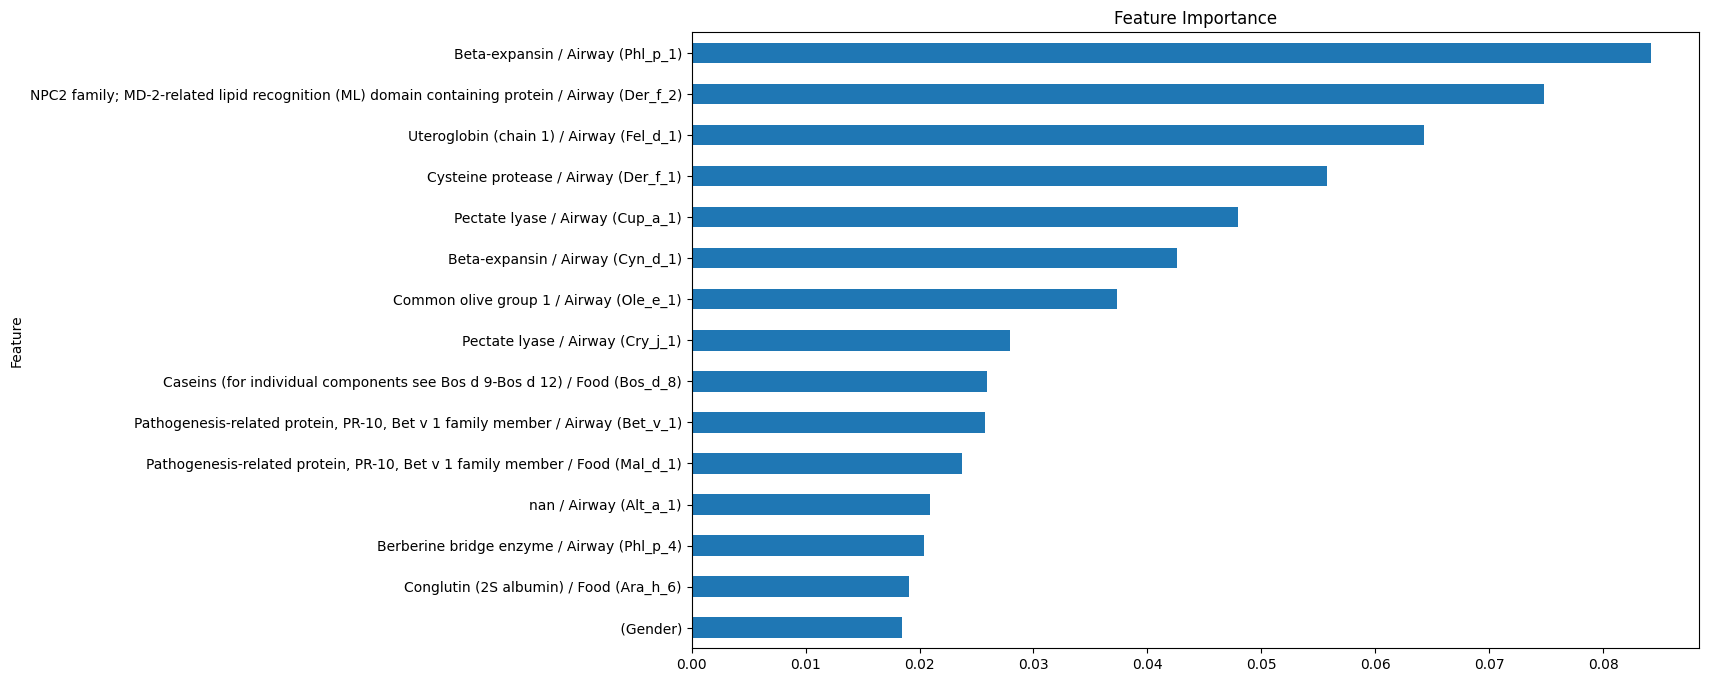

In [61]:
import matplotlib.pyplot as plt

# Get feature importances
index_labels = [f"{dico.get(z.replace('_', ' '), '')} ({z})" for z in X_train.columns]

importances = pd.Series(rfc.feature_importances_, index=index_labels)
importances = importances.sort_values(ascending=False)

# Top 15
importances_z = importances[:15]
importances_z = importances_z.sort_values(ascending=True)

# Plot
plt.figure(figsize=(13, 8))
importances_z.plot(kind='barh')
plt.title("Feature Importance")
plt.ylabel("Feature")
plt.show()